# Composite MNIST multi-label classifier

This notebook clones the repository, downloads datasets from Google Drive, concatenates only their training splits, and evaluates validation/test splits separately.

> **Reproducibility requirement:** Run this notebook on an **NVIDIA A100 GPU in Google Colab**. Select **Runtime → Change runtime type → GPU → A100**, then choose **Runtime → Run all**. Results on other hardware may differ significantly, even with the same seed and deterministic settings.

In [1]:
!pip install -q gdown
!pip install -q matplotlib tqdm

## Configuration

In [2]:
REPO_URL = 'https://github.com/izahai/Multi-Label-Classification-with-MNIST-Digits.git'
BRANCH = 'main'
REPO_DIR = '/content/mnist-detector'

ORIGINAL_DATA_DIR = '/content/mnist-detector/data'
GEN_DATA_DIR = '/content/mnist-detector/data/gen_data'
OUTPUT_DIR = '/content/mnist-detector/results'

MODEL_SIZE = 'densenet_atn_head'  # {'small', 'large', 'dense_net', 'densenet_atn_head'}
EPOCHS = 7
BATCH_SIZE = 256
NUM_WORKERS = 0  # Use 0 for strongest reproducibility across runs
SEED = 42

RESUME_CHECKPOINT = '/content/mnist-detector/results/last.pt'  # Optional path to last.pt on Drive

In [3]:
!git clone --branch "$BRANCH" "$REPO_URL" "$REPO_DIR";
!echo "Repository ready at $REPO_DIR"

Cloning into '/content/mnist-detector'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 156 (delta 80), reused 134 (delta 58), pack-reused 0 (from 0)
Receiving objects: 100% (156/156), 508.94 KiB | 24.23 MiB/s, done.
Resolving deltas: 100% (80/80), done.
Repository ready at /content/mnist-detector


## Download data and generated data

In [4]:
%cd /content/mnist-detector/data
# test.pt
!gdown --fuzzy "https://drive.google.com/file/d/192pw9kbsC7JOMwYUbWOyMppiJ85KDhU1/view?usp=sharing"
# train.pt
!gdown --fuzzy "https://drive.google.com/file/d/12XUEP0MAT_gxNOlOkjliR2ATRmZXNgY0/view?usp=sharing"
# val.pt
!gdown --fuzzy "https://drive.google.com/file/d/10Uk4BTATeUcswQrJXr2rwfL4exkvjSvt/view?usp=drive_link"

# self-generated train.pt
!mkdir gen_data
%cd gen_data
!gdown --fuzzy "https://drive.google.com/file/d/1DbI9glgKuXE0ZhfzHKmYR9Yp9ZBticDj/view?usp=drive_link"
%cd /content/mnist-detector

/content/mnist-detector/data
Downloading...
From (original): https://drive.google.com/uc?id=192pw9kbsC7JOMwYUbWOyMppiJ85KDhU1
From (redirected): https://drive.google.com/uc?id=192pw9kbsC7JOMwYUbWOyMppiJ85KDhU1&confirm=t&uuid=a94e1036-919a-4596-8a4e-77e0598c1074
To: /content/mnist-detector/data/test.pt
100% 44.2M/44.2M [00:00<00:00, 91.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=12XUEP0MAT_gxNOlOkjliR2ATRmZXNgY0
From (redirected): https://drive.google.com/uc?id=12XUEP0MAT_gxNOlOkjliR2ATRmZXNgY0&confirm=t&uuid=93bd0c33-7afa-485e-9721-e99d1bfc866e
To: /content/mnist-detector/data/train.pt
100% 221M/221M [00:02<00:00, 97.5MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=10Uk4BTATeUcswQrJXr2rwfL4exkvjSvt
From (redirected): https://drive.google.com/uc?id=10Uk4BTATeUcswQrJXr2rwfL4exkvjSvt&confirm=t&uuid=ced713cd-aa4b-4f9b-baee-b813bb4507a2
To: /content/mnist-detector/data/val.pt
100% 44.2M/44.2M [00:00<00:00, 64.6MB/s]
/content/mnist-detector/data

In [5]:
from pathlib import Path
import os
import subprocess

required = [
    Path(ORIGINAL_DATA_DIR) / f'{split}.pt'
    for split in ('train', 'val', 'test')
] + [Path(GEN_DATA_DIR) / 'train.pt']
missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError('Missing dataset files:\n' + '\n'.join(missing))
print('Required original splits and generated data training split are available.')

Required original splits and generated data training split are available.


In [6]:
import os
import random
import numpy as np
import torch

# Reproducibility settings (must run before training).
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False

try:
    torch.use_deterministic_algorithms(True)
    print('Deterministic algorithms enabled.')
except Exception as e:
    print('Could not fully enable deterministic algorithms:', e)

print(f'SEED={SEED}, NUM_WORKERS={NUM_WORKERS}')

Deterministic algorithms enabled.
SEED=42, NUM_WORKERS=0


## Train

In [7]:
import subprocess
import shlex
import os
import sys

# Build a deterministic training command.
train_cmd = [
    'python', '-u', '-m', 'src_model_cls.train',
    '--original-data-dir', ORIGINAL_DATA_DIR,
    '--output-dir', OUTPUT_DIR,
    '--model-name', MODEL_SIZE,
    '--epochs', str(EPOCHS),
    '--batch-size', str(BATCH_SIZE),
    '--num-workers', str(NUM_WORKERS),
    '--bbox-data-dir', GEN_DATA_DIR,
]

# Add --seed only if the training module supports it.
help_text = subprocess.run(
    ['python', '-m', 'src_model_cls.train', '--help'],
    check=False, capture_output=True, text=True
).stdout
if '--seed' in help_text:
    train_cmd += ['--seed', str(SEED)]

# if RESUME_CHECKPOINT:
#     train_cmd += ['--resume', RESUME_CHECKPOINT]

print('Running command:')
print(' '.join(shlex.quote(x) for x in train_cmd))

env = os.environ.copy()
env['PYTHONHASHSEED'] = str(SEED)
env['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
env['PYTHONUNBUFFERED'] = '1'

# === SỬ DỤNG POPEN ĐỂ STREAM OUTPUT TRÊN GOOGLE COLAB ===
process = subprocess.Popen(
    train_cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,  # Gộp stderr vào stdout
    text=True,
    bufsize=1,                 # Line buffering
    env=env
)

# Đọc từng dòng log và flush trực tiếp ra cell của Colab
for line in process.stdout:
    print(line, end='')
    sys.stdout.flush()

# Chờ tiến trình kết thúc và kiểm tra lỗi
process.wait()
if process.returncode != 0:
    raise subprocess.CalledProcessError(process.returncode, train_cmd)

Streaming output truncated to the last 5000 lines.
Train: 100%|██████████| 2149/2149 [11:15<00:00,  3.18batch/s, binary=0.996, exact=0.964, loss=0.0125]

Original val: 100%|██████████| 40/40 [00:03<00:00, 10.72batch/s, loss=0.0145]
Train: loss=0.0125 exact=0.9638 binary=0.9957
Validation: loss=0.0145 exact=0.9655 binary=0.9955
Saved new best checkpoint: exact=0.9655, loss=0.0145

Epoch 7/7

Train: 100%|██████████| 2149/2149 [11:15<00:00,  3.18batch/s, binary=0.996, exact=0.970, loss=0.0102]

Original val: 100%|██████████| 40/40 [00:03<00:00, 10.69batch/s, loss=0.0150]
Train: loss=0.0102 exact=0.9698 binary=0.9964
Validation: loss=0.0150 exact=0.9666 binary=0.9957
Saved new best checkpoint: exact=0.9666, loss=0.0150
Saved averaged checkpoint to /content/mnist-detector/results/averaged_top_5.pt

Best: 100%|██████████| 40/40 [00:03<00:00, 10.65batch/s, loss=0.0195]
Best: loss=0.0195 exact=0.9581 binary=0.9946

Top 01 Epoch 007: 100%|██████████| 40/40 [00:03<00:00, 10.73batch/s, loss=0.019

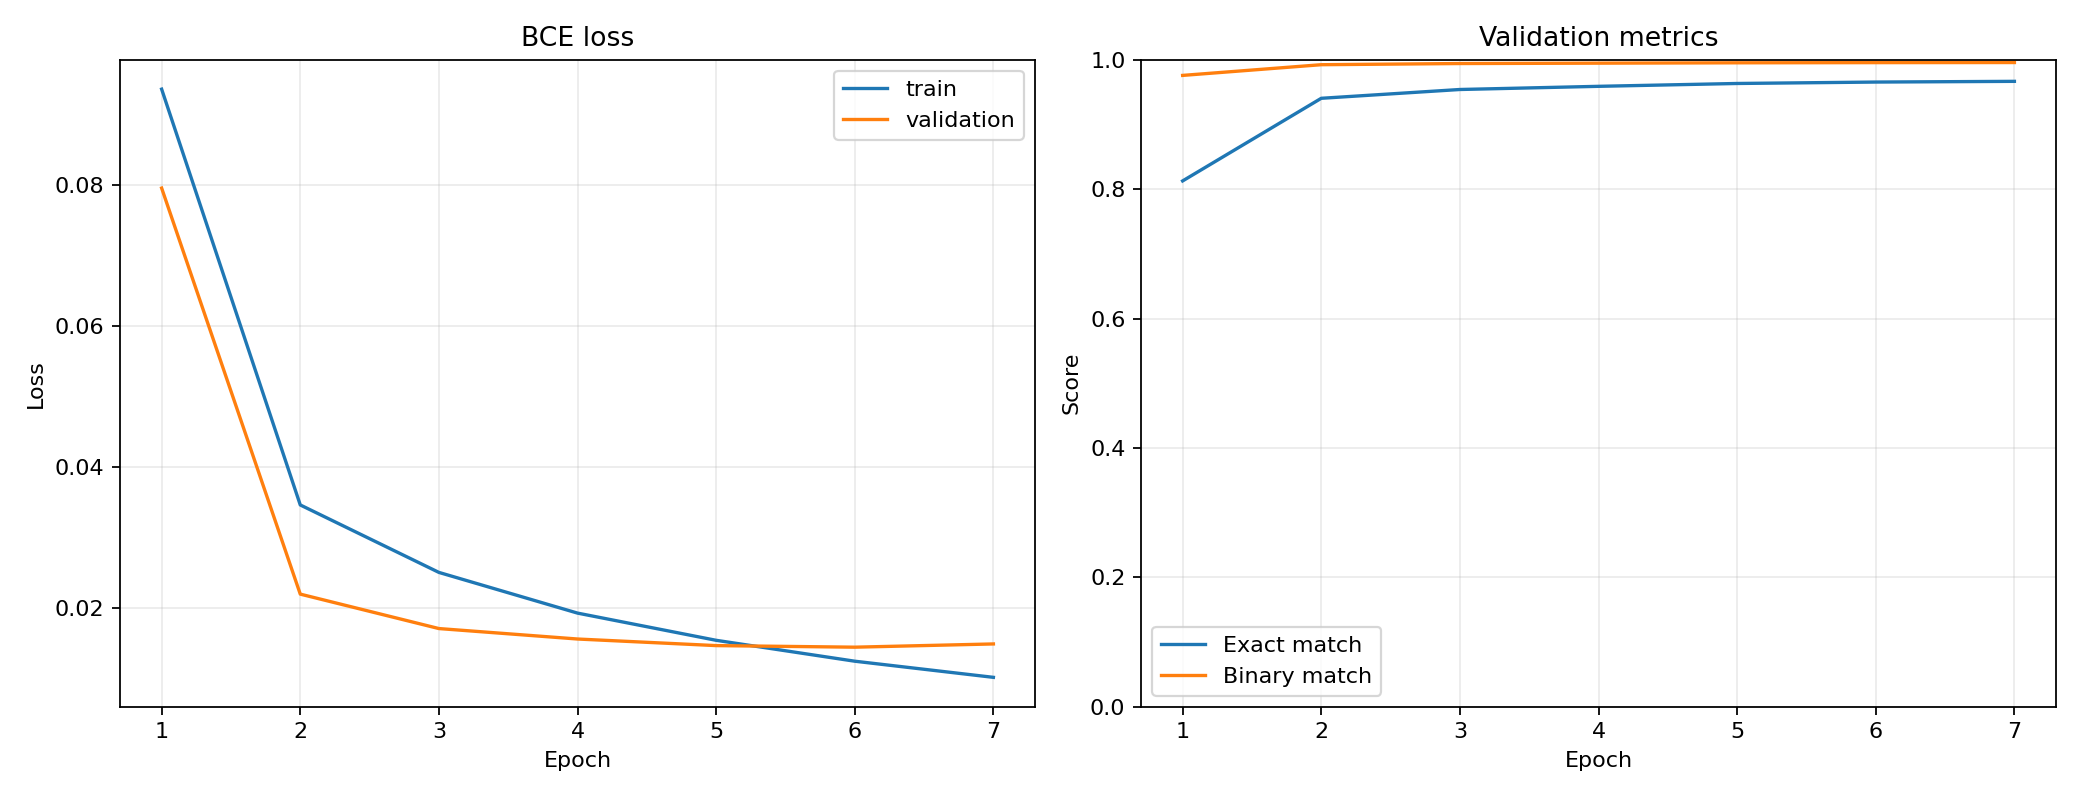

In [9]:
from IPython.display import Image, display

display(Image(filename=str(Path(OUTPUT_DIR) / 'training_curves.png')))

## Test

In [8]:
import json
import pandas as pd

evaluation_path = Path(OUTPUT_DIR) / "evaluation_metrics.json"
CKPT = "/content/mnist-detector/results/top_checkpoints/epoch_001.pt"
BEST = "/content/mnist-detector/results/best.pt"

!python -m src_model_cls.evaluate \
  --checkpoint "{BEST}" \
  --original-data-dir "{ORIGINAL_DATA_DIR}" \
  --splits val test \
  --batch-size {BATCH_SIZE} \
  --num-workers {NUM_WORKERS} \
  --json-output "{evaluation_path}"

with evaluation_path.open() as file:
    results = json.load(file)
pd.DataFrame(results).T[['loss', 'exact_match', 'binary_match']]

Device: cuda
Model: densenet_atn_head
Checkpoint: /content/mnist-detector/results/best.pt
Presence threshold: 0.50
Original Val: 100% 40/40 [00:04<00:00,  9.39batch/s, loss=0.0150]
Original Val: loss=0.0150 exact=0.9666 binary=0.9957
Original Test: 100% 40/40 [00:03<00:00, 11.76batch/s, loss=0.0195]
Original Test: loss=0.0195 exact=0.9581 binary=0.9946
Saved metrics to /content/mnist-detector/results/evaluation_metrics.json


,loss,exact_match,binary_match
original_val,0.014969,0.9666,0.99567
original_test,0.019494,0.9581,0.99456
